# Autoencodeur – pipeline clean (Keras/TensorFlow)

L’objectif de ce notebook est d’explorer la structure latente des profils transcriptomiques RNA-seq de la cohorte TCGA-UCEC à l’aide d’un autoencodeur non supervisé.

Ce notebook est une version **Keras** du pipeline autoencodeur :

- Setup & paramètres
- Autoencodeur Keras pour réduction de dimension (TCGA-UCEC)
- Lecture des données (csv.gz)
- Split 70/30
- Scaling (fit sur train, apply sur train/test/all)
- Entraînement AE
- Extraction de l'espace latent Z (pour toutes les lignes)

# I. Autoencodeur

In [73]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, Model

# -------------------------
# 1) I/O
# -------------------------
EXPR_PATH = r"C:\Users\klerv\Documents\6.M2_AIDA\UE3- AI_DeppLearning\Projet\Data\tcga_ucec_filtered_logCPM_scaled.csv.gz"
META_PATH = r"C:\Users\klerv\Documents\6.M2_AIDA\UE3- AI_DeppLearning\Projet\Data\metadata_clinical_merged.csv.gz"

# -------------------------
# 2) Chargement
# -------------------------
# Hypothèse: lignes = patients, colonnes = gènes (features)
X_df = pd.read_csv(EXPR_PATH, compression="gzip", index_col=0)
meta_df = pd.read_csv(META_PATH, compression="gzip", index_col=0)

# (optionnel) aligner les patients si index identiques
common = X_df.index.intersection(meta_df.index)
X_df = X_df.loc[common].copy()
meta_df = meta_df.loc[common].copy()

print("X shape:", X_df.shape, "| META shape:", meta_df.shape)

# Convert to numpy
X = X_df.to_numpy(dtype=np.float32)


X shape: (553, 21175) | META shape: (553, 175)


In [74]:
input_dim=X.shape[1]
print(input_dim)

21175


## 1. Split 70/30 et Scaling

In [75]:

# -------------------------
# Split 70/30
# -------------------------
SEED = 42
idx_all = np.arange(X.shape[0])

idx_train, idx_test = train_test_split(
    idx_all,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

X_train = X[idx_train]
X_test  = X[idx_test]

# -------------------------
#Scaling (fit sur train)
# -------------------------
scaler = StandardScaler(with_mean=True, with_std=True)
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_all   = scaler.transform(X).astype(np.float32)


print("After scaling -> train:", X_train.shape, "| test:", X_test.shape)


After scaling -> train: (387, 21175) | test: (166, 21175)


In [76]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------
# Split 70/30
# -------------------------
SEED = 42
idx_all = np.arange(X.shape[0])

idx_train, idx_test = train_test_split(
    idx_all,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

X_train_raw = X[idx_train]
X_test_raw  = X[idx_test]

# -------------------------
# Scaling (fit sur train_raw)
# -------------------------
scaler = StandardScaler(with_mean=True, with_std=True)
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)
X_all_s = scaler.transform(X).astype(np.float32)

print("After scaling -> train:", X_train.shape, "| test:", X_test.shape, "| all:", X_all_s.shape)


After scaling -> train: (387, 21175) | test: (166, 21175) | all: (553, 21175)


## 2. Autoencodeur (Dense) + entraînement

### a) Modèle

In [77]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_autoencoder(input_dim, encoding_dim=30, hidden_layers=(128, 64),
                      activation="relu", dropout_rate=0.2):
    """
    Construit un autoencodeur symétrique.
    Retourne: autoencoder, encoder
    """
    # Encoder
    input_layer = keras.layers.Input(shape=(input_dim,), name="input")
    x = input_layer

    for i, units in enumerate(hidden_layers):
        x = keras.layers.Dense(units, activation=activation, name=f"enc_dense_{i}")(x)
        if dropout_rate > 0:
            x = keras.layers.Dropout(dropout_rate, name=f"enc_dropout_{i}")(x)

    # Latent
    encoding = keras.layers.Dense(encoding_dim, activation=activation, name="encoding")(x)

    # Decoder
    x = encoding
    for i, units in enumerate(reversed(hidden_layers)):
        x = keras.layers.Dense(units, activation=activation, name=f"dec_dense_{i}")(x)
        if dropout_rate > 0:
            x = keras.layers.Dropout(dropout_rate, name=f"dec_dropout_{i}")(x)

    output_layer = keras.layers.Dense(input_dim, activation="linear", name="output")(x)

    autoencoder = keras.Model(inputs=input_layer, outputs=output_layer, name="autoencoder")
    encoder = keras.Model(inputs=input_layer, outputs=encoding, name="encoder")
    decoder = keras.Model(encoding, output_layer, name="decoder")

    print(f"Autoencoder construit: {input_dim} → {' → '.join(map(str, hidden_layers))} → {encoding_dim}")

    return autoencoder, encoder, decoder


def train_autoencoder(autoencoder, X_train, epochs=50, batch_size=32,
                      validation_split=0.2, learning_rate=1e-3, verbose=1):
    """
    Entraîne l'autoencodeur.
    Retourne: history (Keras History)
    """
    tf.keras.utils.set_random_seed(42)
    # optionnel: déterminisme (peut ralentir)
    # tf.config.experimental.enable_op_determinism()

    autoencoder.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mse"]
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=10, min_lr=1e-7, verbose=1)
    ]

    print(f"Entraînement autoencoder ({epochs} epochs max, batch={batch_size})")

    history = autoencoder.fit(
        X_train, X_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=callbacks,
        shuffle=True,
        verbose=verbose
    )

    print(f"Entraînement terminé (val_loss finale: {history.history['val_loss'][-1]:.4f})")
    return history

INPUT_DIM = X_train.shape[1]
Latent_DIM = 64
H1= 512
H2= 128
autoencoder, encoder, decoder = build_autoencoder(
    input_dim=INPUT_DIM,
    encoding_dim=Latent_DIM,
    activation="relu",
    hidden_layers=(H1, H2),
    dropout_rate=0.0
)

history_ae = train_autoencoder(
    autoencoder,
    X_train=X_train,
    epochs=200,
    batch_size=32,
    learning_rate=5e-4,
    validation_split=0.2,
    verbose=1
)



Autoencoder construit: 21175 → 512 → 128 → 64
Entraînement autoencoder (200 epochs max, batch=32)
Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 365ms/step - loss: 0.9969 - mse: 0.9969 - val_loss: 0.8445 - val_mse: 0.8445 - learning_rate: 5.0000e-04
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - loss: 0.8415 - mse: 0.8415 - val_loss: 0.7546 - val_mse: 0.7546 - learning_rate: 5.0000e-04
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - loss: 0.7642 - mse: 0.7642 - val_loss: 0.7146 - val_mse: 0.7146 - learning_rate: 5.0000e-04
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - loss: 0.7113 - mse: 0.7113 - val_loss: 0.6855 - val_mse: 0.6855 - learning_rate: 5.0000e-04
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - loss: 0.6628 - mse: 0.6628 - val_loss: 0.6598 - val_mse: 0.6598 - learning_rate: 5.0000e-04
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - loss: 0.6198 - mse: 0.6198 - val_loss: 0.6631 - val_mse: 0.6631 - learning_rate: 5.0000e-04
Epoch 7/200
10/10 ━

### b) Extraction espace latent Z (qui sera utilisé plus tard pour le kNN)

In [78]:

Z_train = encoder.predict(X_train, batch_size=256, verbose=0)
Z_test  = encoder.predict(X_test,  batch_size=256, verbose=0)
Z_all   = encoder.predict(X_all,   batch_size=256, verbose=0)

print("Z_train:", Z_train.shape, "| Z_test:", Z_test.shape, "| Z_all:", Z_all.shape)

# Récupérer en DataFrame avec les mêmes index patients
Z_cols = [f"Z{i+1}" for i in range(Z_all.shape[1])]
Z_df = pd.DataFrame(Z_all, index=X_df.index, columns=Z_cols)

# joindre à la metadata pour analyses ultérieures
metaZ_df = meta_df.join(Z_df, how="inner")



Z_train: (387, 64) | Z_test: (166, 64) | Z_all: (553, 64)


### c) Figure : courbes de loss

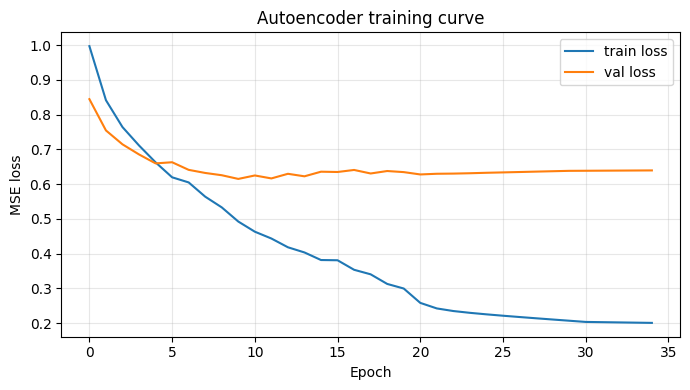

In [79]:
hist_df = pd.DataFrame(history_ae.history)  # contient loss, val_loss, etc.

plt.figure(figsize=(7, 4))
plt.plot(hist_df["loss"], label="train loss")
plt.plot(hist_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### d) Qualité reconstruction

In [80]:
import numpy as np
import pandas as pd

print("="*80)
print("5.1 : QUALITÉ RECONSTRUCTION")
print("="*80)

X_eval = X_all  # ou X_test, ou X_train

if "X_df" in globals() and hasattr(X_df, "index") and len(X_df) == X_eval.shape[0]:
    ids = X_df.index
elif "meta_df" in globals() and hasattr(meta_df, "index") and len(meta_df) == X_eval.shape[0]:
    ids = meta_df.index
else:
    ids = pd.Index(np.arange(X_eval.shape[0]), name="row_id")

# reconstruction ---
X_reconstructed = autoencoder.predict(X_eval, verbose=0)

# MSE par patient ---
mse_per_patient = np.mean((X_eval - X_reconstructed) ** 2, axis=1)
df_mse = pd.DataFrame({"mse": mse_per_patient}, index=ids)

print("\nMSE par patient :")
print(f"  Moyenne: {mse_per_patient.mean():.6f} | Médiane: {np.median(mse_per_patient):.6f}")

# outliers (règle IQR) ---
Q1, Q3 = np.percentile(mse_per_patient, [25, 75])
IQR = Q3 - Q1
thr = Q3 + 1.5 * IQR
outliers = df_mse[df_mse["mse"] > thr]

print(f"  Seuil outlier (Q3 + 1.5*IQR): {thr:.6f}")
print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df_mse)*100:.1f}%)")

print("Evaluation de la qualité de reconstruction terminée.")

5.1 : QUALITÉ RECONSTRUCTION

MSE par patient :
  Moyenne: 0.539132 | Médiane: 0.505509
  Seuil outlier (Q3 + 1.5*IQR): 1.038016
  Outliers: 21 (3.8%)
Evaluation de la qualité de reconstruction terminée.


### e) Tableau autoencodeur : résumé modèle + métriques finales

In [81]:
# Params
autoencoder_params = int(autoencoder.count_params())
enc_params = int(encoder.count_params())
dec_params = int(decoder.count_params())

# Epoch du meilleur val_loss
best_epoch = int(hist_df["val_loss"].idxmin()) + 1
best_val = float(hist_df["val_loss"].min())
best_train_at_best = float(hist_df.loc[best_epoch - 1, "loss"])

# Eval finale (au poids restaurés par EarlyStopping)
train_mse = autoencoder.evaluate(X_train, X_train, verbose=0)[0]
test_mse  = autoencoder.evaluate(X_test,  X_test,  verbose=0)[0]

autoencoder_summary_table = pd.DataFrame([{
    "n_patients_total": X_all.shape[0],
    "n_train": X_train.shape[0],
    "n_test": X_test.shape[0],
    "input_dim": INPUT_DIM,
    "latent_dim": Latent_DIM,
    "hidden_1":H1,
    "hidden_2": H2,
    "batch_size": 32,
    "epochs_ran": len(hist_df),
    "best_epoch_val_loss": best_epoch,
    "best_val_loss": best_val,
    "train_loss_at_best_epoch": best_train_at_best,
    "final_train_mse_eval": train_mse,
    "final_test_mse_eval": test_mse,
    "params_autoencoder": ae_params,
    "params_encoder": enc_params,
    "params_decoder": dec_params
}])

display(autoencoder_summary_table)

autoencoder.summary()       
encoder.summary()   # détail encoder
decoder.summary()   # détail decoder



,n_patients_total,n_train,n_test,input_dim,latent_dim,hidden_1,hidden_2,batch_size,epochs_ran,best_epoch_val_loss,best_val_loss,train_loss_at_best_epoch,final_train_mse_eval,final_test_mse_eval,params_autoencoder,params_encoder,params_decoder
0,553,387,166,21175,64,512,128,32,35,10,0.615134,0.492526,0.492462,0.647935,21853175,10916032,10937143


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21175)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_0 (Dense)             │ (None, 512)            │    10,842,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoding (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21175)          │    10,862,775 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,559,527 (250.09 MB)

 Trainable params: 21,853,175 (83.36 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_44CLONE            │ (None, 64)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21175)          │    10,862,775 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,937,143 (41.72 MB)

 Trainable params: 10,937,143 (41.72 MB)

 Non-trainable params: 0 (0.00 B)

### f) Figure pour visualisation: architecture + UMAP

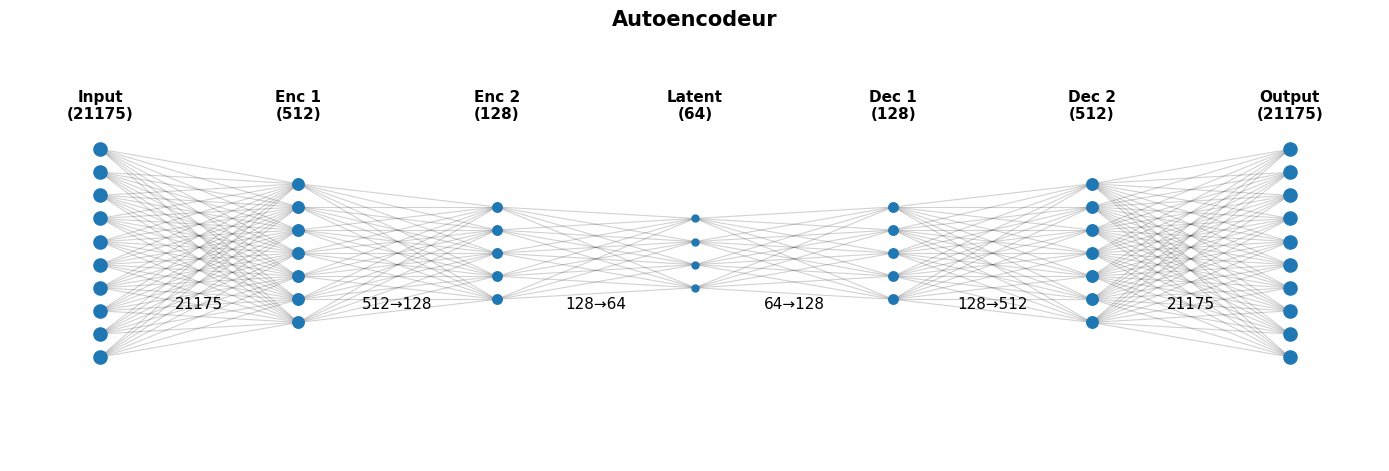

In [82]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_ae_networkx(
    outpath=None,
    title="Autoencodeur",
    layer_sizes=(input_dim, 512, 128, 64, 128, 512, input_dim),
    layer_names=("Input", "Enc 1", "Enc 2", "Latent", "Dec 1", "Dec 2", "Output"),
    max_nodes_per_layer=10,     # nb de neurones dessinés par couche (visuel)
    node_size=220,
    edge_alpha=0.18,
    seed=0
):
    """
    Dessine une architecture d'autoencodeur façon réseau de neurones (NetworkX).
    - layer_sizes: tailles réelles (labels)
    - max_nodes_per_layer: nb de neurones dessinés (pour éviter 350*... sur la figure)
    """

    rng = np.random.default_rng(seed)

    # --- helper: combien de neurones afficher par couche
    def display_count(n):
        return int(min(max_nodes_per_layer, max(3, round(np.sqrt(n))))) if n > max_nodes_per_layer else int(n)
        # alternative plus simple: return min(max_nodes_per_layer, n)

    # --- disp en V : peu de noeuds au latent, plus aux extrémités ---
    latent_idx = layer_names.index("Latent") if "Latent" in layer_names else (len(layer_sizes) // 2)
    max_dist = max(latent_idx, (len(layer_sizes) - 1) - latent_idx)

    MIN_NODES = 4                  # nb min de noeuds affichés au latent
    MAX_NODES = max_nodes_per_layer  # nb max affiché aux extrémités

    def n_vis_for_layer(li: int) -> int:
        d = abs(li - latent_idx)
        t = d / max_dist if max_dist > 0 else 0.0  # 0 au latent, 1 aux extrémités
        n = int(round(MIN_NODES + (MAX_NODES - MIN_NODES) * (t**1.6)))  # 1.6 = accentue l'effet
        # ne pas dépasser la taille réelle de la couche
        return int(min(layer_sizes[li], max(3, n)))
    disp = [n_vis_for_layer(li) for li in range(len(layer_sizes))]


    # --- construire le graphe
    G = nx.DiGraph()

    # positions des neurones (x = couche, y = index)
    pos = {}
    node_layer = {}

    x_spacing = 2.2
    y_spacing = 1.0

    # pour centrer verticalement chaque couche
    for li, (n_real, n_vis) in enumerate(zip(layer_sizes, disp)):
        x = li * x_spacing
        ys = np.linspace(-(n_vis - 1) / 2, (n_vis - 1) / 2, n_vis) * y_spacing

        # Si couche très grande mais on en affiche peu: on ajoute des "..." au milieu
        show_ellipsis = (n_real > n_vis)

        # indices affichés (on prend haut/bas + quelques au milieu si besoin)
        if show_ellipsis and n_vis >= 6:
            # ex: 10 -> [0,1,2, ..., 7,8,9]
            top_k = n_vis // 2
            bot_k = n_vis - top_k
            # on garde tout mais on marquera l'ellipsis sur le milieu
            idxs = list(range(n_vis))
            ellipsis_idx = n_vis // 2
        else:
            idxs = list(range(n_vis))
            ellipsis_idx = None

        for j in idxs:
            nid = f"L{li}_N{j}"
            G.add_node(nid)
            pos[nid] = (x, ys[j])
            node_layer[nid] = li

        # marquer un nœud "..." si utile (non connecté, juste décor)
        if show_ellipsis and ellipsis_idx is not None:
            eid = f"L{li}_ELLIPSIS"
            G.add_node(eid)
            pos[eid] = (x, ys[ellipsis_idx])
            node_layer[eid] = li

    # --- connecter densément couche->couche (entre neurones "visuels")
    for li in range(len(layer_sizes) - 1):
        left_nodes = [n for n in G.nodes if node_layer.get(n) == li and not n.endswith("ELLIPSIS")]
        right_nodes = [n for n in G.nodes if node_layer.get(n) == li + 1 and not n.endswith("ELLIPSIS")]
        for a in left_nodes:
            for b in right_nodes:
                G.add_edge(a, b)

    # --- dessin
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.set_axis_off()

    # couleurs par bloc (encoder/latent/decoder)
    layer_colors = []
    for li in range(len(layer_sizes)):
        if li == latent_idx:
            layer_colors.append("lightgray")     # latent
        else:
            layer_colors.append("white")        

    # edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        arrows=False,
        alpha=edge_alpha,
        width=0.8
    )

    # --- paramètres tailles ---
    MIN_SIZE = 25      # taille au latent
    MAX_SIZE = 90      # taille aux extrémités (input/output)

    latent_idx = layer_names.index("Latent") if "Latent" in layer_names else (len(layer_sizes) // 2)
    max_dist = max(latent_idx, (len(layer_sizes) - 1) - latent_idx)

    def node_size_for_layer(li: int) -> float:
        d = abs(li - latent_idx)              # distance à la couche latent
        t = d / max_dist if max_dist > 0 else 0.0  # normalisé [0,1]
        return MIN_SIZE + (MAX_SIZE - MIN_SIZE) * t

    # nodes couche par couche (taille dépendante de la couche)
    for li in range(len(layer_sizes)):
        nodes_li = [n for n in G.nodes if node_layer.get(n) == li and not n.endswith("ELLIPSIS")]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodes_li,
            node_size=node_size_for_layer(li),
            node_color="#1f77b4",
            ax=ax
        )


    # labels au-dessus de chaque couche
    y_top = max(y for _, y in pos.values()) + 1.2
    for li, (name, n_real) in enumerate(zip(layer_names, layer_sizes)):
        x = li * x_spacing
        ax.text(x, y_top, f"{name}\n({n_real})", ha="center", va="bottom", fontsize=11, fontweight="bold")

    # flèches / transitions
    # on place le texte entre les couches, au milieu vertical
    transitions = [input_dim, "512→128", "128→64", "64→128", "128→512", input_dim]
    y_mid = 0.0
    for li, lab in enumerate(transitions):
        x = (li * x_spacing + (li + 1) * x_spacing) / 2
        ax.text(x, y_mid - 2.2, lab, ha="center", va="center", fontsize=11)

    # titre
    ax.text(
        (len(layer_sizes) - 1) * x_spacing / 2,
        y_top + 4.0,
        title,
        ha="center",
        va="bottom",
        fontsize=15,
        fontweight="bold"
    )

    # limites
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - 1.0, max(xs) + 1.0)
    ax.set_ylim(min(ys) - 4.5, y_top + 2.0)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        svg_path = os.path.splitext(outpath)[0] + ".svg"
        plt.savefig(svg_path, bbox_inches="tight")
        print("Saved:", outpath)
        print("Saved:", svg_path)

        plt.show()


# IMPORTANT : appeler la fonction
plot_ae_networkx()




c:\Users\klerv\Documents\Python\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


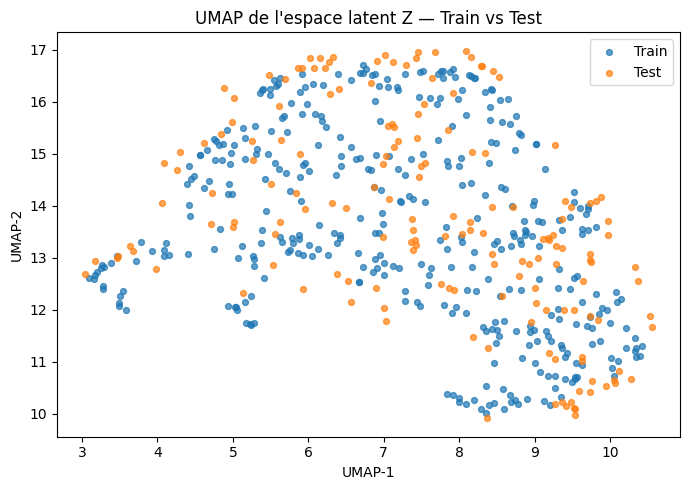

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# UMAP
import umap.umap_ as umap

# ----------------------------
# B) Sinon : split rapide 70/30 sur Z_df
# ----------------------------
from sklearn.model_selection import train_test_split
all_ids = Z_df.index.to_numpy()
train_ids, test_ids = train_test_split(all_ids, test_size=0.30, random_state=42)

# ----------------------------
# 1) Matrices Z (latent)
# ----------------------------
Z_train = Z_df.loc[train_ids].to_numpy(dtype=float)
Z_test  = Z_df.loc[test_ids].to_numpy(dtype=float)


# ----------------------------
# 2) UMAP fit sur train, transform sur test
# ----------------------------
um = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)

U_train = um.fit_transform(Z_train)
U_test  = um.transform(Z_test)

# ----------------------------
# 3) Plot train vs test
# ----------------------------
plt.figure(figsize=(7, 5))
plt.scatter(U_train[:, 0], U_train[:, 1], s=18, alpha=0.7, label="Train")
plt.scatter(U_test[:, 0],  U_test[:, 1],  s=18, alpha=0.7, label="Test")

plt.title("UMAP de l'espace latent Z — Train vs Test")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()


# II. Analyse des 10 plus proches voisins avec kNN

Télécharger la feature survie à 5 ans

In [84]:
meta_df = meta_df.copy()

meta_df["survival_days"] = pd.to_numeric(meta_df["paper_os_days"], errors="coerce")

mask_deceased_5y = (meta_df["paper_vital_status"] == "DECEASED") & (meta_df["survival_days"] <= 1825)
mask_alive_5y    = (meta_df["paper_vital_status"] == "LIVING")   & (meta_df["survival_days"] > 1825)

meta_df["OS_5years"] = np.nan
meta_df.loc[mask_deceased_5y, "OS_5years"] = 0
meta_df.loc[mask_alive_5y,    "OS_5years"] = 1


print(
    "OS_5years labeled:", meta_df["OS_5years"].notna().sum(),
    "| deaths<=5y:", int((meta_df["OS_5years"] == 1).sum()),
    "| alive>5y:", int((meta_df["OS_5years"] == 0).sum())
)


OS_5years labeled: 82 | deaths<=5y: 46 | alive>5y: 36


Sélection des 10 plus proches voisins

In [85]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# 1) mettre les IDs en index (UNE fois)
if "sample_barcode" in X_df.columns:
    X_df = X_df.set_index("sample_barcode")

if "barcode" in meta_df.columns:
    meta_df = meta_df.set_index("barcode")

# 2) choisir un patient_id qui existe dans les 2 tables
common_ids = X_df.index.intersection(meta_df.index)
patient_id = common_ids.to_series().sample(1, random_state=42).iloc[0]

print("patient_id =", patient_id, "| common_ids =", len(common_ids))

from sklearn.neighbors import NearestNeighbors
import numpy as np

# --- 1) Assurer que les IDs sont en index (recommandé)
if "sample_barcode" in Z_df.columns:
    Z_df = Z_df.set_index("sample_barcode")

# (optionnel mais utile) aligner sur meta_df si meta_df est indexé par "barcode"
common_ids = Z_df.index.intersection(meta_df.index)
meta_df_knn = meta_df.drop(columns=["paper_recurred_progressed"], errors="ignore") #ignore cette colonne pour l'analyse suivante


# --- 2) Choisir un patient_id si pas déjà défini
if "patient_id" not in globals():
    rng = np.random.default_rng(42)
    patient_id = rng.choice(common_ids)
    print("patient_id choisi:", patient_id)

# --- 3) kNN dans Z pour obtenir les 10 voisins
k = 10
Z_mat = Z_df.loc[common_ids].to_numpy(dtype=float)
ids = common_ids.to_numpy()

nn = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
nn.fit(Z_mat)

i = np.where(ids == patient_id)[0][0]
dists, idxs = nn.kneighbors(Z_mat[i:i+1], return_distance=True)

idxs = idxs[0]
dists = dists[0]

mask = idxs != i  # retire le patient lui-même
neighbor_ids = ids[idxs[mask]][:k]
neighbor_dists = dists[mask][:k]

print("neighbors:", neighbor_ids)
print("dists    :", neighbor_dists)
 


patient_id = TCGA-B5-A0JS-01A-11R-A104-07 | common_ids = 553
neighbors: ['TCGA-D1-A16D-01A-11R-A12I-07' 'TCGA-BS-A0TC-01A-11R-A104-07'
 'TCGA-BG-A0VV-01A-21R-A118-07' 'TCGA-D1-A1NS-01A-11R-A14D-07'
 'TCGA-BS-A0UA-01A-11R-A118-07' 'TCGA-B5-A11Y-01A-21R-A10J-07'
 'TCGA-B5-A0K2-01A-12R-A104-07' 'TCGA-EC-A24G-01A-11R-A16F-07'
 'TCGA-BS-A0TD-01A-11R-A104-07' 'TCGA-D1-A17U-01A-21R-A12I-07']
dists    : [39.17093354 47.2744808  51.13333809 51.68979648 52.64463957 54.53471101
 55.13219347 55.58785408 56.018538   56.62715356]


## 1. Trouver les 10 plus proches voisins avec les données transcriptomiques

In [86]:
# ---------------------------------------------------------
# 0) Paramètres
# ---------------------------------------------------------
TOP_K_GENES = 20

# Colonnes cliniques pertinentes (on ne garde que celles qui existent)
KEEP = [
    "paper_age", "paper_histological_type", "paper_tumor_grade", "paper_figo_stage",
    "paper_msi_status", "paper_POLE_status", "paper_tp53_mut",
    "paper_recurred_progressed", "OS_5years",
    "paper_os_days", "paper_vital_status"
]
KEEP = [c for c in KEEP if c in meta_df_knn.columns]

# ---------------------------------------------------------
# 1) Tableau patient + voisins (clinique + distances)
# ---------------------------------------------------------
def table_patient_neighbors(meta_df_knn, patient_id, neighbor_ids, neighbor_dists, keep_cols):
    rows = [patient_id] + list(neighbor_ids)
    tab = meta_df_knn.loc[rows, keep_cols].copy()

    tab.insert(0, "role", ["patient"] + [f"neighbor_{i+1}" for i in range(len(neighbor_ids))])
    tab.insert(1, "patient", rows)

    # distance au patient (0 pour patient)
    dist_col = np.concatenate([[0.0], np.asarray(neighbor_dists, dtype=float)])
    tab.insert(2, "dist_in_Z", dist_col)

    return tab.reset_index(drop=True)

df_neighbors = table_patient_neighbors(meta_df_knn, patient_id, neighbor_ids, neighbor_dists, KEEP)

display(Markdown("## Tableau 1 — Patient sélectionné et ses 10 plus proches voisins (espace latent Z)"))
display(df_neighbors)

# ---------------------------------------------------------
# 2) Tableau gènes similaires / différents
# ---------------------------------------------------------
def gene_neighbor_tables(X_df, patient_id, neighbor_ids, top_k=25):
    x_pat = X_df.loc[patient_id]
    x_nei = X_df.loc[neighbor_ids]

    mu = x_nei.mean(axis=0)
    sd = x_nei.std(axis=0).replace(0, np.nan)

    z = (x_pat - mu) / sd

    df = pd.DataFrame({
        "gene": X_df.columns,
        "patient_expr": x_pat.values,
        "neighbors_mean": mu.values,
        "neighbors_sd": sd.values,
        "delta_patient_minus_neighbors": (x_pat - mu).values,
        "z_vs_neighbors": z.values,
        "abs_z": np.abs(z.values),
    }).dropna(subset=["abs_z"])

    # plus similaires = abs_z petit
    genes_most_similar = (
        df.sort_values("abs_z", ascending=True)
          .head(top_k)
          .reset_index(drop=True)
    )

    # plus différents = abs_z grand
    genes_most_different = (
        df.sort_values("abs_z", ascending=False)
          .head(top_k)
          .reset_index(drop=True)
    )

    # colonnes à afficher
    cols = ["gene", "patient_expr", "neighbors_mean", "neighbors_sd",
            "delta_patient_minus_neighbors", "z_vs_neighbors", "abs_z"]

    return genes_most_similar[cols], genes_most_different[cols]

df_genes_sim, df_genes_diff = gene_neighbor_tables(X_df, patient_id, neighbor_ids, top_k=TOP_K_GENES)

display(Markdown(f"## Tableau 2 — Top {TOP_K_GENES} gènes les plus similaires (patient ≈ moyenne des voisins)"))
display(df_genes_sim)

display(Markdown(f"## Tableau 3 — Top {TOP_K_GENES} gènes les plus différents (patient ≠ moyenne des voisins)"))
display(df_genes_diff)


## Tableau 1 — Patient sélectionné et ses 10 plus proches voisins (espace latent Z)

,role,patient,dist_in_Z,paper_age,paper_tumor_grade,OS_5years,paper_os_days,paper_vital_status
0,patient,TCGA-B5-A0JS-01A-11R-A104-07,0.000000,54.0,Grade 1,NaN,1422,LIVING
1,neighbor_1,TCGA-D1-A16D-01A-11R-A12I-07,39.170934,49.0,Grade 2,NaN,1141,LIVING
2,neighbor_2,TCGA-BS-A0TC-01A-11R-A104-07,47.274481,69.0,Grade 1,1.0,2260,LIVING
3,neighbor_3,TCGA-BG-A0VV-01A-21R-A118-07,51.133338,53.0,Grade 1,NaN,260,LIVING
4,neighbor_4,TCGA-D1-A1NS-01A-11R-A14D-07,51.689796,53.0,Grade 1,NaN,43,LIVING
5,neighbor_5,TCGA-BS-A0UA-01A-11R-A118-07,52.644640,68.0,Grade 1,1.0,2540,LIVING
6,neighbor_6,TCGA-B5-A11Y-01A-21R-A10J-07,54.534711,59.0,Grade 1,NaN,559,LIVING
7,neighbor_7,TCGA-B5-A0K2-01A-12R-A104-07,55.132193,54.0,Grade 1,NaN,788,LIVING
8,neighbor_8,TCGA-EC-A24G-01A-11R-A16F-07,55.587854,57.0,Grade 3,NaN,46,LIVING
9,neighbor_9,TCGA-BS-A0TD-01A-11R-A104-07,56.018538,65.0,Grade 1,1.0,2002,LIVING


## Tableau 2 — Top 20 gènes les plus similaires (patient ≈ moyenne des voisins)

,gene,patient_expr,neighbors_mean,neighbors_sd,delta_patient_minus_neighbors,z_vs_neighbors,abs_z
0,CABP4,-0.021209,-0.021219,0.500306,0.000010,0.000020,0.000020
1,TMLHE,0.409399,0.409421,0.352831,-0.000022,-0.000062,0.000062
2,PRDM10,-0.434247,-0.434180,0.602892,-0.000067,-0.000111,0.000111
3,DAP3,-0.666586,-0.666518,0.469913,-0.000068,-0.000145,0.000145
4,MAX,0.011981,0.011865,0.632287,0.000116,0.000183,0.000183
5,ABCG5,-0.204250,-0.204115,0.593748,-0.000135,-0.000228,0.000228
6,ING5,-0.986270,-0.985955,1.020555,-0.000316,-0.000309,0.000309
7,ISLR2,0.256489,0.256721,0.717380,-0.000232,-0.000323,0.000323
8,EEF1GP1,-0.269683,-0.269408,0.696636,-0.000275,-0.000395,0.000395
9,MMP2,0.008818,0.008613,0.445103,0.000205,0.000461,0.000461


## Tableau 3 — Top 20 gènes les plus différents (patient ≠ moyenne des voisins)

,gene,patient_expr,neighbors_mean,neighbors_sd,delta_patient_minus_neighbors,z_vs_neighbors,abs_z
0,GLIS3-AS1,5.443933,-0.241478,0.261743,5.685410,21.721319,21.721319
1,BMP5,0.854097,-0.481031,0.066592,1.335128,20.049276,20.049276
2,AC010491.2,2.752162,-0.190603,0.177335,2.942765,16.594409,16.594409
3,NELL1,2.993020,-0.467047,0.226045,3.460068,15.306953,15.306953
4,NEUROG2,3.089508,-0.174703,0.255455,3.264211,12.778042,12.778042
5,XPNPEP2,2.083129,-0.390604,0.233145,2.473734,10.610274,10.610274
6,ZNF486,3.386454,-0.413111,0.371927,3.799566,10.215903,10.215903
7,GACAT3,0.794823,-0.525610,0.130003,1.320433,10.156923,10.156923
8,LRCOL1,1.248531,-0.557667,0.191485,1.806198,9.432573,9.432573
9,MMP26,1.640591,-0.429115,0.237911,2.069705,8.699491,8.699491


## 2. Caractéristiques métacliniques des 10 plus proches voisins

In [87]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ---------------------------------------------------------
# 0) Tableau patient + voisins (clinique + distances)
# ---------------------------------------------------------
def table_patient_neighbors(meta_df_knn, patient_id, neighbor_ids, neighbor_dists, keep_cols):
    rows = [patient_id] + list(neighbor_ids)
    tab = meta_df_knn.loc[rows, keep_cols].copy()

    tab.insert(0, "role", ["patient"] + [f"neighbor_{i+1}" for i in range(len(neighbor_ids))])
    tab.insert(1, "patient_id", rows)

    dist_col = np.concatenate([[0.0], np.asarray(neighbor_dists, dtype=float)])
    tab.insert(2, "dist_in_Z", dist_col)

    return tab.reset_index(drop=True)

display(Markdown("## Tableau 1 — Patient sélectionné et ses 10 plus proches voisins (espace latent Z)"))
display(table_patient_neighbors(meta_df_knn, patient_id, neighbor_ids, neighbor_dists, KEEP))

# ---------------------------------------------------------
# 1) Tables métacliniques similaires / différentes
# ---------------------------------------------------------
def meta_neighbor_tables(meta_df_knn, patient_id, neighbor_ids,
                         exclude_cols=("paper_recurred_progressed", "OS_5years"),
                         top_k=20,
                         min_nonmissing=6,
                         min_unique=2):
    """
    Retourne:
      - df_meta_sim: top_k variables métacliniques les plus similaires
      - df_meta_diff: top_k variables métacliniques les plus différentes

    Numérique:
      abs_z = |(patient - mean_neighbors)/sd_neighbors|
    Catégoriel:
      diff_score = 1 - match_prop
    """

    patient = meta_df_knn.loc[patient_id]
    neigh = meta_df_knn.loc[neighbor_ids]

    # Exclure colonnes qui ne doivent pas servir à "expliquer"
    cols = [c for c in meta_df_knn.columns if c not in exclude_cols]
    # Filtrer colonnes trop "ID/admin" (tu peux enrichir si besoin)
    bad_patterns = ["uuid","barcode","submitter","sample","case","project","program","timestamp","date","time"]
    def is_bad(c):
        cl = c.lower()
        return any(p in cl for p in bad_patterns)

    cols = [c for c in cols if not is_bad(c)]

    cols = [c for c in cols if not c.lower().endswith((".x", ".y", "_x", "_y"))]

    rows = []
    for c in cols:
        x_pat = patient[c]
        x_nei = neigh[c]

        nn = int(x_nei.notna().sum())
        if nn < min_nonmissing:
            continue

        nuniq = int(x_nei.dropna().nunique())
        if nuniq < min_unique:
            continue

        # Numérique
        if pd.api.types.is_numeric_dtype(x_nei):
            x_pat_num = pd.to_numeric(pd.Series([x_pat]), errors="coerce").iloc[0]
            x_nei_num = pd.to_numeric(x_nei, errors="coerce")

            mu = x_nei_num.mean()
            sd = x_nei_num.std()

            if pd.isna(x_pat_num) or pd.isna(mu) or pd.isna(sd) or sd == 0:
                continue

            z = (x_pat_num - mu) / sd
            rows.append({
                "feature": c,
                "type": "numeric",
                "patient_value": x_pat_num,
                "neighbors_mean": float(mu),
                "neighbors_sd": float(sd),
                "delta_patient_minus_neighbors": float(x_pat_num - mu),
                "z_vs_neighbors": float(z),
                "diff_score": float(abs(z)),  # plus petit = plus similaire
                "n_neighbors_nonmissing": nn,
                "neighbors_unique_values": nuniq
            })

        # Catégoriel
        else:
            if pd.isna(x_pat):
                continue
            match_prop = float((x_nei == x_pat).sum() / nn)
            mode = x_nei.dropna().mode()
            mode = mode.iloc[0] if len(mode) else np.nan

            rows.append({
                "feature": c,
                "type": "categorical",
                "patient_value": x_pat,
                "neighbors_mode": mode,
                "neighbors_match_patient_prop": match_prop,
                "diff_score": float(1 - match_prop),  # plus petit = plus similaire
                "n_neighbors_nonmissing": nn,
                "neighbors_unique_values": nuniq
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df, df

    # Tables finales
    df_sim = df.sort_values("diff_score", ascending=True).head(top_k).reset_index(drop=True)
    df_diff = df.sort_values("diff_score", ascending=False).head(top_k).reset_index(drop=True)

    return df_sim, df_diff

TOP_K_META = 20
df_meta_sim, df_meta_diff = meta_neighbor_tables(
    meta_df, patient_id, neighbor_ids,
    top_k=TOP_K_META
)

display(Markdown(f"## Tableau 2 — Top {TOP_K_META} variables métacliniques les plus similaires (patient ≈ voisins)"))
display(df_meta_sim)

display(Markdown(f"## Tableau 3 — Top {TOP_K_META} variables métacliniques les plus différentes (patient ≠ voisins)"))
display(df_meta_diff)


## Tableau 1 — Patient sélectionné et ses 10 plus proches voisins (espace latent Z)

,role,patient_id,dist_in_Z,paper_age,paper_tumor_grade,OS_5years,paper_os_days,paper_vital_status
0,patient,TCGA-B5-A0JS-01A-11R-A104-07,0.000000,54.0,Grade 1,NaN,1422,LIVING
1,neighbor_1,TCGA-D1-A16D-01A-11R-A12I-07,39.170934,49.0,Grade 2,NaN,1141,LIVING
2,neighbor_2,TCGA-BS-A0TC-01A-11R-A104-07,47.274481,69.0,Grade 1,1.0,2260,LIVING
3,neighbor_3,TCGA-BG-A0VV-01A-21R-A118-07,51.133338,53.0,Grade 1,NaN,260,LIVING
4,neighbor_4,TCGA-D1-A1NS-01A-11R-A14D-07,51.689796,53.0,Grade 1,NaN,43,LIVING
5,neighbor_5,TCGA-BS-A0UA-01A-11R-A118-07,52.644640,68.0,Grade 1,1.0,2540,LIVING
6,neighbor_6,TCGA-B5-A11Y-01A-21R-A10J-07,54.534711,59.0,Grade 1,NaN,559,LIVING
7,neighbor_7,TCGA-B5-A0K2-01A-12R-A104-07,55.132193,54.0,Grade 1,NaN,788,LIVING
8,neighbor_8,TCGA-EC-A24G-01A-11R-A16F-07,55.587854,57.0,Grade 3,NaN,46,LIVING
9,neighbor_9,TCGA-BS-A0TD-01A-11R-A104-07,56.018538,65.0,Grade 1,1.0,2002,LIVING


## Tableau 2 — Top 20 variables métacliniques les plus similaires (patient ≈ voisins)

,feature,type,patient_value,neighbors_mode,neighbors_match_patient_prop,diff_score,n_neighbors_nonmissing,neighbors_unique_values,neighbors_mean,neighbors_sd,delta_patient_minus_neighbors,z_vs_neighbors
0,paper_race,categorical,WHITE,WHITE,0.800000,0.200000,10,2,NaN,NaN,NaN,NaN
1,paper_X2009stagegroup,categorical,Stage I,Stage I,0.800000,0.200000,10,3,NaN,NaN,NaN,NaN
2,paper_disease_status_at_lfu,categorical,NoDisease,NoDisease,0.800000,0.200000,10,2,NaN,NaN,NaN,NaN
3,paper_histology_grade,categorical,EndoGr1,EndoGr1,0.700000,0.300000,10,3,NaN,NaN,NaN,NaN
4,paper_tumor_grade,categorical,Grade 1,Grade 1,0.700000,0.300000,10,3,NaN,NaN,NaN,NaN
5,treatments_pharmaceutical_treatment_or_therapy,categorical,no,no,0.700000,0.300000,10,4,NaN,NaN,NaN,NaN
6,days_to_collection,numeric,1183.0,NaN,NaN,0.317437,10,10,887.0,932.469958,296.0,0.317437
7,treatments_pharmaceutical_treatment_intent_type,categorical,Adjuvant;NA,Adjuvant;NA,0.666667,0.333333,6,2,NaN,NaN,NaN,NaN
8,treatments_radiation_treatment_or_therapy,categorical,no,no,0.600000,0.400000,10,2,NaN,NaN,NaN,NaN
9,treatments_radiation_treatment_type,categorical,"Radiation Therapy, NOS","Radiation Therapy, NOS",0.600000,0.400000,10,3,NaN,NaN,NaN,NaN


## Tableau 3 — Top 20 variables métacliniques les plus différentes (patient ≠ voisins)

,feature,type,patient_value,neighbors_mode,neighbors_match_patient_prop,diff_score,n_neighbors_nonmissing,neighbors_unique_values,neighbors_mean,neighbors_sd,delta_patient_minus_neighbors,z_vs_neighbors
0,paper_cna_cluster_k4,numeric,2.0,NaN,NaN,1.161895,10,2,1.400000,0.516398,0.600000,1.161895
1,paper_mrna_expression_cluster,numeric,2.0,NaN,NaN,1.054093,9,2,2.555556,0.527046,-0.555556,-1.054093
2,patient,categorical,TCGA-B5-A0JS,TCGA-B5-A0K2,0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
3,paper_os_days,categorical,1422,1141,0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
4,treatments_radiation_treatment_id,categorical,0a4ac920-0ab5-4ef4-8028-e414792cb831,002afe07-a1a0-5d19-babf-29c713364fa6,0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
5,treatments_pharmaceutical_treatment_id,categorical,96cf4c75-104b-516c-be24-5c709faaa2cc;b6ffb67a-...,00b4f097-8c81-4e86-88a4-faddb4eb5a63;422869ff-...,0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
6,paper_patient,categorical,TCGA-B5-A0JS,TCGA-B5-A0K2,0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
7,paper_BMI,categorical,"38,062283737","24,0054869685",0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
8,paper_pfs_days,categorical,1422,1141,0.000000,1.000000,10,10,NaN,NaN,NaN,NaN
9,paper_ethnicity,categorical,Unknown,NOT HISPANIC OR LATINO,0.200000,0.800000,10,2,NaN,NaN,NaN,NaN


#### Analyse risque de progression de la maladie chez le sujet (target="paper_recurred_progressed")

Patient: TCGA-BG-A0M8-01A-12R-A104-07
Vérité paper_recurred_progressed: 0  (1=Yes event, 0=No event)
--------------------------------------------
Voisins labellisés: n=10 | Yes= 3 | No= 7
Risk Yes = 0.300   (≈ 3/10)
Risk No  = 0.700
IC95% Risk Yes (Wilson): [0.108, 0.603]


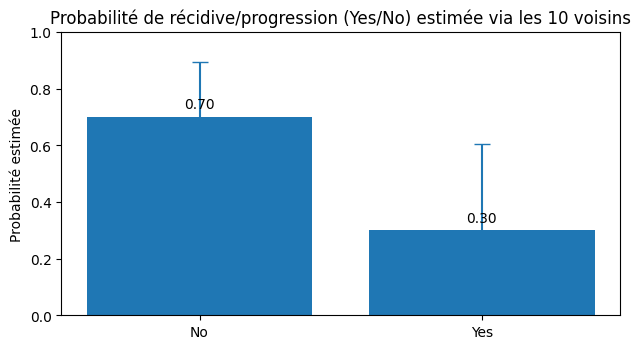

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "paper_recurred_progressed"

def _to01(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    m = s.astype(str).str.strip().str.lower()
    mapping = {"1":1,"0":0,"yes":1,"no":0,"true":1,"false":0,"y":1,"n":0}
    out = m.map(mapping)
    out2 = pd.to_numeric(m, errors="coerce")
    out = out.where(~out.isna(), out2)
    return out.astype(float)

def wilson_ci(k, n, z=1.959963984540054):
    """IC95% Wilson pour proportion k/n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    half = (z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))

def plot_risk_yes_no(meta_df, patient_id, neighbor_ids, target=TARGET, show_ci=True, title=None):
    y01 = _to01(meta_df[target])

    y_pat = y01.loc[patient_id]
    if pd.isna(y_pat):
        raise ValueError(f"Patient {patient_id} sans label connu pour {target}")

    y_nei = y01.loc[list(neighbor_ids)]
    known = y_nei.dropna()

    n = int(len(known))
    if n == 0:
        raise ValueError("Aucun voisin labellisé -> impossible de calculer risk")

    k_yes = int(known.sum())
    risk_yes = k_yes / n
    risk_no  = 1 - risk_yes

    # IC95%
    lo, hi = wilson_ci(k_yes, n)
    # pour NO c'est complémentaire (approx) : [1-hi, 1-lo]
    lo_no, hi_no = 1 - hi, 1 - lo

    # print lisible
    print("============================================")
    print(f"Patient: {patient_id}")
    print(f"Vérité {target}: {int(y_pat)}  (1=Yes event, 0=No event)")
    print("--------------------------------------------")
    print(f"Voisins labellisés: n={n} | Yes= {k_yes} | No= {n-k_yes}")
    print(f"Risk Yes = {risk_yes:.3f}   (≈ {k_yes}/{n})")
    print(f"Risk No  = {risk_no:.3f}")
    if show_ci:
        print(f"IC95% Risk Yes (Wilson): [{lo:.3f}, {hi:.3f}]")
    print("============================================")

    # ---- VISU : 2 barres Yes / No
    labels = ["No", "Yes"]
    probs = [risk_no, risk_yes]

    plt.figure(figsize=(6.4, 3.6))
    bars = plt.bar(labels, probs)
    plt.ylim(0, 1)
    plt.ylabel("Probabilité estimée")
    plt.title(title or f"Probabilité estimée (kNN) — {target}")

    # valeurs sur les barres
    for b, p in zip(bars, probs):
        plt.text(b.get_x() + b.get_width()/2, p + 0.02, f"{p:.2f}", ha="center", va="bottom", fontsize=10)

    # option: barres d'erreur IC95% sur Yes/No
    if show_ci:
        # erreur asymétrique pour Yes
        err_yes = [[risk_yes - lo], [hi - risk_yes]]  # [[down],[up]]
        # pour No (complément)
        err_no  = [[risk_no - lo_no], [hi_no - risk_no]]

        # positions 0(No), 1(Yes)
        plt.errorbar([0], [risk_no], yerr=err_no, fmt="none", capsize=6)
        plt.errorbar([1], [risk_yes], yerr=err_yes, fmt="none", capsize=6)

    plt.tight_layout()
    plt.show()

    return {
        "risk_yes": float(risk_yes),
        "risk_no": float(risk_no),
        "n_labeled_neighbors": n,
        "k_yes": k_yes,
        "ci95_yes": (float(lo), float(hi)) if show_ci else None
    }

# -------------------------
# UTILISATION : réutilise ta sélection précédente
# -------------------------
patient_id_prev = res["patient_id"]
neighbor_ids_prev = res["neighbor_ids"]

out = plot_risk_yes_no(
    meta_df,
    patient_id=patient_id_prev,
    neighbor_ids=neighbor_ids_prev,
    target="paper_recurred_progressed",
    show_ci=True,
    title="Probabilité de récidive/progression (Yes/No) estimée via les 10 voisins"
)




#### UMAP représentation du sujet avec ses 10 plus proches voisins

c:\Users\klerv\Documents\Python\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


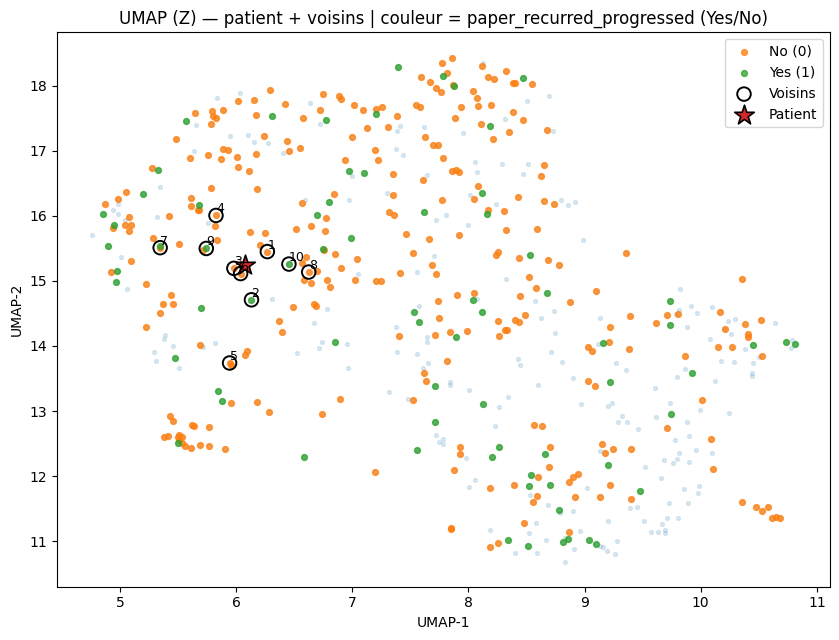

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "paper_recurred_progressed"

def _to01(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    m = s.astype(str).str.strip().str.lower()
    mapping = {"1":1,"0":0,"yes":1,"no":0,"true":1,"false":0,"y":1,"n":0}
    out = m.map(mapping)
    out2 = pd.to_numeric(m, errors="coerce")
    out = out.where(~out.isna(), out2)
    return out.astype(float)

def plot_umap_patient_neighbors(
    meta_df: pd.DataFrame,
    Z_all,
    patient_id: str,
    neighbor_ids,
    target: str = TARGET,
    umap_n_neighbors: int = 30,
    umap_min_dist: float = 0.15,
    random_state: int = 42,
    annotate_neighbors: bool = True
):
    # --- import UMAP
    try:
        import umap
    except Exception as e:
        raise ImportError(
            "Le package 'umap-learn' n'est pas installé. "
            "Installe-le avec: pip install umap-learn"
        ) from e

    if not isinstance(Z_all, np.ndarray):
        Z_all = np.asarray(Z_all)

    idx = meta_df.index
    if Z_all.shape[0] != len(idx):
        raise ValueError(f"Z_all ({Z_all.shape[0]}) != meta_df ({len(idx)}). Il faut réaligner.")

    neighbor_ids = list(neighbor_ids)
    if patient_id not in idx:
        raise ValueError("patient_id pas dans meta_df.index")
    for nid in neighbor_ids:
        if nid not in idx:
            raise ValueError(f"neighbor_id absent de meta_df.index: {nid}")

    # --- labels 0/1
    y01 = _to01(meta_df[target])  # float, NaN possible
    labeled_mask = y01.notna().values

    # --- UMAP sur Z
    reducer = umap.UMAP(
        n_neighbors=umap_n_neighbors,
        min_dist=umap_min_dist,
        metric="euclidean",
        random_state=random_state
    )
    U = reducer.fit_transform(Z_all)  # (n,2)

    # --- positions patient/voisins
    i_pat = idx.get_loc(patient_id)
    i_nei = [idx.get_loc(nid) for nid in neighbor_ids]

    # --- plot
    plt.figure(figsize=(8.5, 6.5))

    # 1) tout le dataset en gris (contexte)
    plt.scatter(U[:,0], U[:,1], s=8, alpha=0.15)

    # 2) points labellisés colorés Yes/No
    y_lab = y01.values
    mask_no  = labeled_mask & (y_lab == 0)
    mask_yes = labeled_mask & (y_lab == 1)

    plt.scatter(U[mask_no,0],  U[mask_no,1],  s=18, alpha=0.75, label="No (0)")
    plt.scatter(U[mask_yes,0], U[mask_yes,1], s=18, alpha=0.75, label="Yes (1)")

    # 3) voisins : cercles entourés
    plt.scatter(U[i_nei,0], U[i_nei,1], s=95, facecolors="none", edgecolors="black", linewidths=1.4, label="Voisins")

    # 4) patient : étoile
    plt.scatter(U[i_pat,0], U[i_pat,1], s=220, marker="*", edgecolors="black", linewidths=1.2, label="Patient")

    # annotations (optionnel)
    if annotate_neighbors:
        for r, j in enumerate(i_nei, start=1):
            plt.text(U[j,0], U[j,1], str(r), fontsize=9, ha="left", va="bottom")

    plt.title(f"UMAP (Z) — patient + voisins | couleur = {target} (Yes/No)")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    return U

# -------------------------
# UTILISATION (réutilise ta sélection précédente)
# -------------------------
U = plot_umap_patient_neighbors(
    meta_df=meta_df,
    Z_all=Z_all,
    patient_id=res["patient_id"],
    neighbor_ids=res["neighbor_ids"],
    target="paper_recurred_progressed",
    umap_n_neighbors=30,
    umap_min_dist=0.15,
    random_state=42,
    annotate_neighbors=True
)
